In [ ]:
import cmdstanpy
cmdstanpy.install_cmdstan()
from cmdstanpy import CmdStanModel

/media/brasammy/5B6DAD9B6A1F7E40/Projects/Thesis/Main/Final_work/thesis/myenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CmdStan install directory: /home/brasammy/.cmdstan
CmdStan version 2.36.0 already installed
Test model compilation


In [11]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
from cmdstanpy import CmdStanModel, cmdstan_path
import arviz as az
from pathlib import Path

from loadData import load_data
from imputeMissing import impute_value

from scipy.integrate import odeint

import logging
cmdstanpy_logger = logging.getLogger("cmdstanpy")
cmdstanpy_logger.disabled = True

# 1 . Data Generation with disease induced Deaths

# 1 . META POPULATION MODEL - NO TRAVEL
$$
\begin{aligned}
S'_{p} &= -\sum_{j=1}^n \beta_{j}\frac{S_{p}I_{j}}{N_j} \\
E'_{p} &= \sum_{j=1}^n \beta_{j}\frac{S_{p}I_{j}}{N_j} - \sigma_{p} E_{p}\\
I'_{p} &= \sigma_{p} E_{p} - (\gamma_{p} + \alpha_{p}) I_{p} \\
R'_{p} &= \gamma_{p} I_{p}\\
D'_{p} &= \alpha_{p} I_{p}
\end{aligned}
$$

Where:
- $ S_p, E_p, I_p, R_p $: Susceptible, Exposed, Infectious, and Recovered individuals in patch $ p $.
- $ N_p $: Total population for patch $ p $.
- $ \beta_{j} $: Transmission rate in patch $ p $ with individual contact from patch $j$.
- $ \sigma_{p} $: Rate of progression from Exposed to Infectious (inverse of the latent period).
- $ \gamma_{p} $: Recovery rate (inverse of the infectious period).
- $ \alpha_{p}$: Disease induced death rate.

In [ ]:
# Define the SEIR model differential equations
def seir_model(state, t, N, beta, sigma, gamma, alpha):
    n_patches = len(N)
    S = state[:n_patches]
    E = state[n_patches:2*n_patches]
    I = state[2*n_patches:3*n_patches]
    R = state[3*n_patches:4*n_patches]
    D = state[4*n_patches:5*n_patches]
    C = state[5*n_patches:]  # Cumulative cases

    dSdt = np.zeros(n_patches)
    dEdt = np.zeros(n_patches)
    dIdt = np.zeros(n_patches)
    dRdt = np.zeros(n_patches)
    dDdt = np.zeros(n_patches)
    dCdt = np.zeros(n_patches)

    for p in range(n_patches):
        # Force of infection for patch p from all patches j
        foi = sum(beta[p, j] * S[p] * I[j] / N[j] for j in range(n_patches))
        dSdt[p] = -foi
        dEdt[p] = foi - sigma[p] * E[p]
        dIdt[p] = sigma[p] * E[p] - (gamma[p] + alpha[p]) * I[p]
        dRdt[p] = gamma[p] * I[p]
        dDdt[p] = alpha[p] * I[p]
        dCdt[p] = sigma[p] * E[p]

    return np.concatenate([dSdt, dEdt, dIdt, dRdt, dDdt, dCdt])

In [ ]:
n_patches = 3 
T = 96 #679/7
# Time vector
t = np.linspace(0, T, T)

N = [11.5e6, 4.5e6, 6.8e6]  # Guinea, Liberia, Sierra Leone
# N=[1000000, 960000, 745000]
# N = np.array([110000, 440000, 680000])

## Get the Parameters

beta = np.array([[0.3, 0.03, 0.035], 
           [0.03, 0.4, 0.05], 
           [0.035, 0.05, 0.35]])*7
sigma = np.array([1/8.5, 1/8.5, 1/8.5])*7
gamma = np.array([1/13, 1/14, 1/13])*7    # 1/infectious period (Ebola: ~7 days)
alpha = np.array([0.06, 0.06, 0.06])*7

phi = 10           # Negative binomial dispersion parameter
reporting_rate = 1 #0.8  # Proportion of cases reported

## Get initials
# guinea = [N[0]-1000, 0, 1000, 0, 1000]
# lib = [N[1]-100, 0, 100, 0, 100]
# sir = [N[2]-100, 0, 100, 0, 100]

# Initial conditions
E0 = np.array([10, 10, 10])
I0 = np.array([10, 10, 10])
R0 = np.array([0,0,0])
D0 = np.array([0,0,0])
C0 = np.array([0,0,0])
S0 = np.array([N[0]-10, N[1]-10, N[2]-10])

# initial_state = [guinea, lib, sir]
y0 = np.concatenate([S0.flatten(), E0.flatten(), I0.flatten(), R0.flatten(), D0.flatten(), C0.flatten()])


In [ ]:

# Solve the ODE system
solution = odeint(seir_model, y0, t, args=(N, beta, sigma, gamma, alpha))

# Extract variables
S = solution[:, :n_patches]
E = solution[:, n_patches:2*n_patches]
I = solution[:, 2*n_patches:3*n_patches]
R = solution[:, 3*n_patches:4*n_patches]
D = solution[:, 4*n_patches:5*n_patches]
C = solution[:, 5*n_patches:]

## Total per patch (sum over resident patches i)
S_total = S #np.sum(S, axis=1)
E_total = E #np.sum(E, axis=1)
I_total = I #np.sum(I, axis=1)
R_total = R #np.sum(R, axis=1)
C_total = C #np.sum(C, axis=1)
D_total = D #np.sum(D, axis=1)

In [67]:
C_total

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.79988994e+01, 1.83940340e+01, 1.83253348e+01],
       [6.68785683e+01, 6.95785016e+01, 6.87641475e+01],
       [1.91678909e+02, 2.02742084e+02, 1.98707728e+02],
       [5.10673191e+02, 5.47998560e+02, 5.32972382e+02],
       [1.32814783e+03, 1.44227628e+03, 1.39339341e+03],
       [3.42695460e+03, 3.75621772e+03, 3.60905134e+03],
       [8.82080741e+03, 9.73338017e+03, 9.31306691e+03],
       [2.26784381e+04, 2.51172405e+04, 2.39720685e+04],
       [5.81762850e+04, 6.43688396e+04, 6.14448420e+04],
       [1.48287149e+05, 1.62382305e+05, 1.55883526e+05],
       [3.71660082e+05, 3.94627150e+05, 3.85519105e+05],
       [8.94579646e+05, 8.83410364e+05, 8.98898372e+05],
       [1.97730620e+06, 1.70106730e+06, 1.86379090e+06],
       [3.77946649e+06, 2.67148999e+06, 3.22409402e+06],
       [6.00237928e+06, 3.47008379e+06, 4.57303180e+06],
       [8.01711737e+06, 3.96935116e+06, 5.55571285e+06],
       [9.45135785e+06, 4.23680

In [ ]:
## get the new infected individuals at each time
Infections = np.zeros([T, n_patches])
Deaths = np.zeros([T, n_patches])

for j in range(3):
    ## get new infections
    for i in (range(len(C_total))):

        if (i+1 == len(C_total)):
            new_infections = [0.0,0.0,0.0]
            Infections[i, j] = new_infections[j]
        else:
            new_infections = C_total[i+1] - C_total[i]
            Infections[i+1, j] = new_infections[j]

# get new deaths
    for i in (range(len(D_total))):

        if (i+1 == len(D_total)):
            new_deaths = [0.0,0.0,0.0]
            Deaths[i, j] = new_deaths[j]
        else:
            new_deaths = D_total[i+1] - D_total[i]
            Deaths[i+1, j] = new_deaths[j]

In [69]:
## Function to add noise
def Add_noise(data, reporting_rate):
    observed_cases = []
    for i in range(len(np.array(data))):
        case = []
        for t in range(len(np.array(data)[i])):
            mean_cases = reporting_rate * np.array(data)[i][t]

            # Negative binomial: r = phi (dispersion), p = phi/(phi + mean)
            p = phi / (phi + mean_cases)
            case.append(np.random.negative_binomial(phi, p))
        observed_cases.append(case)
    return np.array(observed_cases)


In [70]:
Infections[:10]

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.79988994e+01, 1.83940340e+01, 1.83253348e+01],
       [4.88796689e+01, 5.11844676e+01, 5.04388127e+01],
       [1.24800341e+02, 1.33163582e+02, 1.29943581e+02],
       [3.18994282e+02, 3.45256476e+02, 3.34264653e+02],
       [8.17474636e+02, 8.94277718e+02, 8.60421026e+02],
       [2.09880677e+03, 2.31394144e+03, 2.21565794e+03],
       [5.39385282e+03, 5.97716245e+03, 5.70401557e+03],
       [1.38576307e+04, 1.53838603e+04, 1.46590016e+04],
       [3.54978468e+04, 3.92515992e+04, 3.74727734e+04]])

In [ ]:
observed_cases = Add_noise(Infections, reporting_rate= reporting_rate)
observed_deaths = Add_noise(Deaths, reporting_rate= reporting_rate)
c = pd.DataFrame(observed_cases, columns = ['Guinea', 'Liberia', 'Sierra Leone'])
d = pd.DataFrame(observed_deaths, columns = ['Guinea', 'Liberia', 'Sierra Leone'])

In [ ]:
# Create dataset
data = {
    'time': pd.date_range(start='2013-12-28', periods=T, freq='D'),
    'Day': t.astype(int),
    'S_Guinea': S_total[:, 0],
    'E_Guinea': E_total[:, 0],
    'I_Guinea': I_total[:, 0],
    'R_Guinea': R_total[:, 0],
    'D_Guinea': D_total[:, 0],
    'C_Guinea': C_total[:, 0],
    'Guinea_New_case': Infections[:, 0],
    'Guinea_Noise' : c['Guinea'],
    'Guinea_New_Deaths': Deaths[:, 0],
    'Guinea_Death_Noise' : d['Guinea'],

    'S_Liberia': S_total[:, 1],
    'E_Liberia': E_total[:, 1],
    'I_Liberia': I_total[:, 1],
    'R_Liberia': R_total[:, 1],
    'D_Liberia': D_total[:, 1],
    'C_Liberia': C_total[:, 1],
    'Liberia_New_case': Infections[:, 1],
    'Liberia_Noise' : c['Liberia'],
    'Liberia_New_Deaths': Deaths[:, 1],
    'Liberia_Death_Noise' : d['Liberia'],

    'S_SierraLeone': S_total[:, 2],
    'E_SierraLeone': E_total[:, 2],
    'I_SierraLeone': I_total[:, 2],
    'R_SierraLeone': R_total[:, 2],
    'D_SierraLeone': D_total[:, 2],
    'C_SierraLeone': C_total[:, 2],
    'SierraLeone_New_case': Infections[:, 2],
    'SierraLeone_Noise' : c['Sierra Leone'],
    'SierraLeone_New_Deaths': Deaths[:, 2],
    'SierraLeone_Death_Noise' : d['Sierra Leone'],
}

raw_coupling = pd.DataFrame(data)
raw_coupling.to_csv('Data/coupling_synthetic_ebola_dataset_with_death.csv', index=False)
raw_coupling.head()

,time,Day,S_Guinea,E_Guinea,I_Guinea,R_Guinea,C_Guinea,Guinea_New_case,Guinea_Noise,S_Liberia,...,C_Liberia,Liberia_New_case,Liberia_Noise,S_SierraLeone,E_SierraLeone,I_SierraLeone,R_SierraLeone,C_SierraLeone,SierraLeone_New_case,SierraLeone_Noise
0,2013-12-28,0,1.149999e+07,10.000000,10.000000,0.000000,0.000000,0.000000,0,4.499990e+06,...,0.000000,0.000000,0,6.799990e+06,10.000000,10.000000,0.000000,0.000000,0.000000,0
1,2013-12-29,1,1.149995e+07,35.251754,20.402082,7.596817,17.998899,17.998899,20,4.499945e+06,...,18.394034,18.394034,27,6.799946e+06,36.137109,20.678821,7.646514,18.325335,18.325335,14
2,2013-12-30,2,1.149984e+07,90.546810,51.128804,25.749765,66.878568,48.879669,38,4.499835e+06,...,69.578502,51.184468,32,6.799837e+06,93.836928,52.560887,26.203261,68.764147,50.438813,34
3,2013-12-31,3,1.149958e+07,231.072395,129.967859,71.711051,191.678909,124.800341,160,4.499549e+06,...,202.742084,133.163582,126,6.799560e+06,241.332940,134.965930,73.741798,198.707728,129.943581,98
4,2014-01-01,4,1.149890e+07,591.333794,331.815996,188.857195,510.673191,318.994282,188,4.498809e+06,...,547.998560,345.256476,465,6.798846e+06,620.973682,347.050920,195.921462,532.972382,334.264653,226


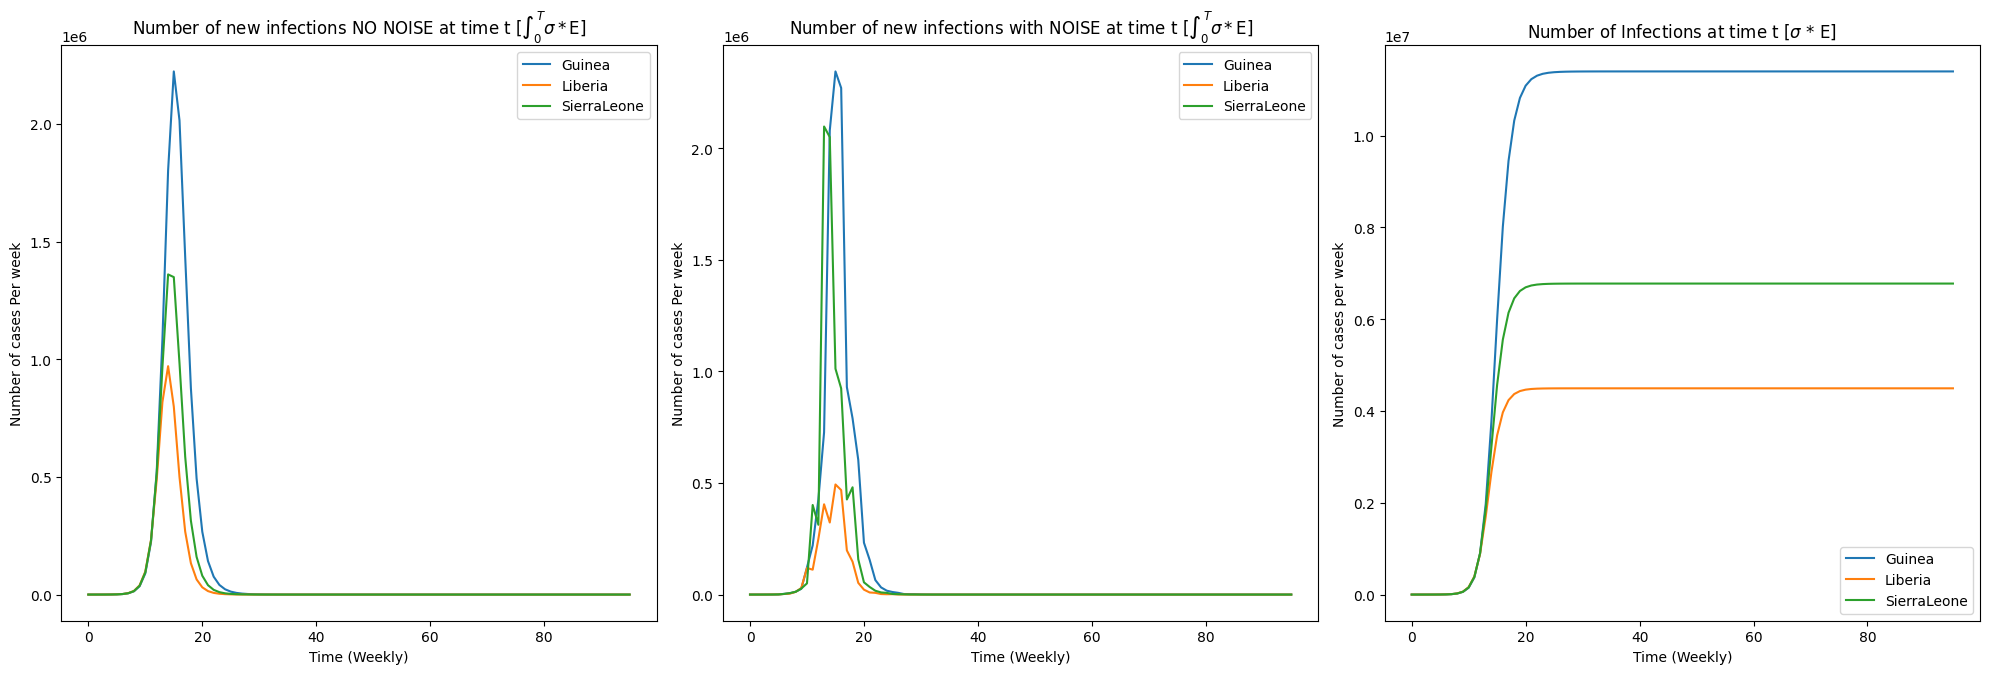

In [73]:
fig, ax = plt.subplots(1,3, figsize = (20,7))
countries = ['Guinea', 'Liberia', 'SierraLeone']
for i in range(3):
    ax[0].plot(raw_coupling[f'{countries[i]}_New_case'])
    ax[0].legend(countries)
    ax[0].set_title('Number of new infections NO NOISE at time t $[\int_0^T \sigma*$E]')
    ax[0].set_xlabel('Time (Weekly)')
    ax[0].set_ylabel('Number of cases Per week')

    ax[1].plot(raw_coupling[f'{countries[i]}_Noise'])
    ax[1].legend(countries)
    ax[1].set_title('Number of new infections with NOISE at time t $[\int_0^T \sigma*$E]')
    ax[1].set_xlabel('Time (Weekly)')
    ax[1].set_ylabel('Number of cases Per week')

    ax[2].plot(raw_coupling[f'C_{countries[i]}'])
    ax[2].legend(countries)
    ax[2].set_title('Number of Infections at time t [$ \sigma$ * E]')
    ax[2].set_xlabel('Time (Weekly)')
    ax[2].set_ylabel('Number of cases per week')

plt.tight_layout()
plt.show()

## Fit the Model

In [74]:
weekly_coupling = raw_coupling[['Guinea_Noise', 'Liberia_Noise', 'SierraLeone_Noise']]
weekly_coupling.head()

,Guinea_Noise,Liberia_Noise,SierraLeone_Noise
0,0,0,0
1,20,27,14
2,38,32,34
3,160,126,98
4,188,465,226


In [75]:

N = np.array([11.5e6, 4.5e6, 6.8e6]) 
# N = np.array([2e6, 1.5e6, 1e6])
# N = np.array([110000, 440000, 680000])
# Set the population size

g0 = np.array([N[0]-10, 10, 10, 0])
l0 = np.array([N[1]-10, 10, 10, 0])
s0 = np.array([N[2]-10, 10, 10, 0])

y0 = np.concatenate([g0, l0, s0]).flatten()

ts = weekly_coupling.values.T

# beta = np.array([0.3, 0.4, 0.35])*7
beta = np.array([[0.3, 0.03, 0.035], 
           [0.03, 0.4, 0.05], 
           [0.035, 0.05, 0.35]])*7
sigma = np.array([1/8.5, 1/8.5, 1/8.5])*7
gamma = np.array([1/13, 1/14, 1/13])*7 

phi = 10           # Negative binomial dispersion parameter
alpha = 0.05*7
reporting_rate = 1  

# Make the data struture
seir_data = {
    'N_patches': 3,
    "n_weeks": len(ts[0]),
    'y0': y0,
    't0': 0,
    "t": np.arange(1, len(ts[0])+1),
    "N": N.astype(int),
    "cases": ts,
    'beta_data': beta,
    'sigma_data': sigma,
    'gamma_data': gamma,
    'reporting_rate': reporting_rate
}

coupling_model = CmdStanModel(stan_file = 'stan files/metapopulation.stan')

In [ ]:
fit_coupling_model = coupling_model.sample(data = seir_data,
                                           iter_sampling = 2000,
                                           parallel_chains=True,
                                           chains = 4,
                                           seed = 0)

chain 1 |          | 00:00 Status


chain 1 |██████████| 34:30 Iteration: 1900 / 2000 [ 95%]  (Sampling)
































































chain 1 |██████████| 6:04:22 Sampling completed                     
chain 2 |██████████| 6:04:22 Sampling completed                       
chain 3 |██████████| 6:04:22 Sampling completed                       
chain 4 |██████████| 6:04:22 Sampling completed                       

In [77]:
coupling_summary = fit_coupling_model.summary()
coupling_summary.filter(items=("beta[1]","beta[2]", "beta[3]", "sigma[1]","sigma[2]","sigma[3]",
                                 "gamma[1]","gamma[2]", 'gamma[3]', 
                                "recovery_time[1]","recovery_time[2]", "recovery_time[3]",
                                 "incubation_period[1]",'incubation_period[2]', 'incubation_period[3]', 
                                 "R0[1]","R0[2]", "R0[3]", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma[1],0.875994,0.002620,0.140402,0.128123,0.691330,0.855348,1.139250,3183.62,2981.32,0.999758
sigma[2],0.869056,0.001812,0.096782,0.087980,0.740581,0.857241,1.045310,3441.19,2540.90,1.002240
sigma[3],0.834062,0.001753,0.095144,0.087019,0.707629,0.820068,1.013790,3344.01,2395.98,1.000350
gamma[1],0.625459,0.001801,0.090289,0.069383,0.519163,0.608391,0.795354,3275.39,2314.48,1.001010
gamma[2],0.575423,0.001196,0.070800,0.066792,0.471875,0.568860,0.696773,3782.61,2705.07,1.003980
gamma[3],0.596998,0.001417,0.079008,0.070125,0.487553,0.587461,0.739205,3611.87,2510.69,1.002340
recovery_time[1],1.627440,0.003749,0.203789,0.187882,1.257300,1.643680,1.926180,3275.39,2314.48,1.001060
recovery_time[2],1.763350,0.003470,0.210998,0.205777,1.435180,1.757910,2.119210,3782.62,2705.07,1.004130
recovery_time[3],1.702480,0.003559,0.211367,0.204910,1.352800,1.702250,2.051060,3611.86,2510.69,1.002350
incubation_period[1],1.168450,0.003071,0.172359,0.178127,0.877774,1.169120,1.446490,3183.57,2981.32,0.999789


In [80]:
# Extract posterior samples
posterior = fit_coupling_model.draws_pd()

## save the posterior samples
posterior.to_csv('./Data/posterior_samples_coupling.csv', index=False)

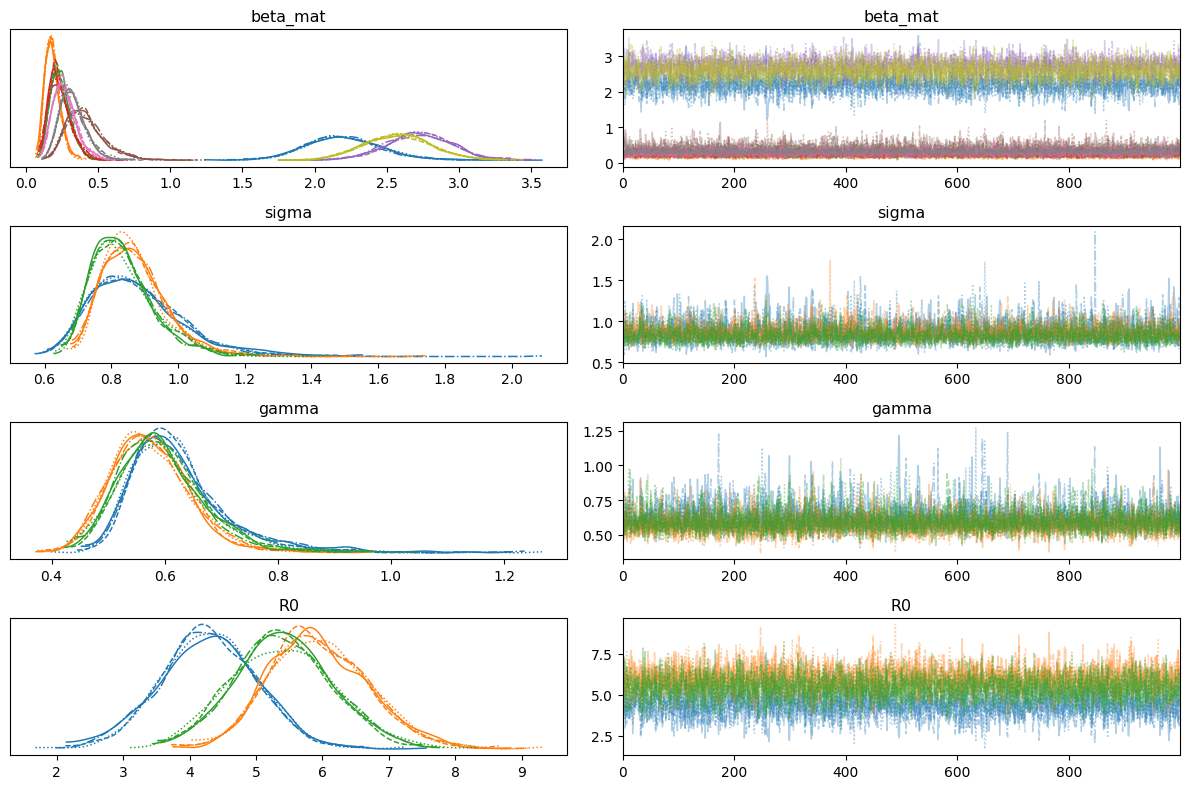

In [79]:

az.plot_trace(fit_coupling_model, var_names=["beta_mat", "sigma", "gamma", "R0"])
plt.tight_layout()
plt.show()

## 2 . Create the SEIRD Patch model

### simple model with Death compartment

---
### Residents of patch i currently in patch i

---

$$
\begin{aligned}
{S'}_{ii} &= -\sum_{k=1}^n \beta_{ik} \frac{S_{ii} I_{kj}}{N_j} + \sum_{k=1}^n r_{ij} S_{ii} - g_i S_{ii} \\
{E'}_{ii} &= \sum_{k=1}^n \beta_{ik} \frac{S_{ii} I_{kj}}{N_j} - \sigma E_{ii} + \sum_{k=1}^n r_{ij} E_{ii} - g_i E_{ii} \\
{I'}_{ii} &= \sigma E_{ii} - (\gamma + \alpha) I_{ii} + \sum_{k=1}^n r_{ij} I_{ii} - g_i I_{ii} \\
{R'}_{ii} &= \gamma I_{ii} + \sum_{k=1}^n r_{ij} R_{ii} - g_i R_{ii} \\
{D'}_{ii} &= \alpha I_{ii}
\end{aligned}
$$

---
### Residents of patch i currently in patch j

---
$$
\begin{aligned}
S'_{ij} &= -\sum_{k=1}^n k_j \beta_{ikj}\frac{S_{ij}I_{kj}}{N_j} + g_i m_{ji}S_{ii} - r_{ij}S_{ij}\\
E'_{ij} &= \sum_{k=1}^n k_j \beta_{ikj}\frac{S_{ij}I_{kj}}{N_j} - \sigma E_{ij} + g_i m_{ji}E_{ii} - r_{ij}E_{ij}\\
I'_{ij} &= \sigma E_{ij} - (\gamma + \alpha)I_{ij} + g_im_{ji}I_{ii} - r_{ij}I_{ij}\\
R'_{ij} &= \gamma I_{ij} + g_im_{ji}R_{ii} - r_{ij}R_{ij}\\
D'_{ij} &= \alpha I_{ij}
\end{aligned}
$$


- $S, E, I, R, D$: Susceptible, Exposed, Infectious, Recovered, and Dead compartments
- $\beta_{ik}$: Transmission rate from patch k to individuals in patch i
- $\sigma$: Rate at which exposed individuals become infectious (1/incubation period)
- $\gamma$: Recovery rate for infectious individuals
- $\alpha$: Disease-induced death rate
- $g_i$: Rate at which individuals leave patch i
- $r_{ij}$: Rate of return from patch j to patch i
- $m_{ji}$: fraction of individuals from patch i to patch j
- $k_j$: contact rate in patch j
- $N_j$: Total population in patch j

---
## Likelihoods
$$observed\_cases[t,p]∼ \text{NegativeBinomial}(ρ[p]×incidence[t,p],ϕ)$$

$$observed\_deaths[t,p]∼\text{NegativeBinomial}(ρ_d[p]×predicted\_deaths[t,p],ϕ_d)$$

Where:
- $\rho[p]$: Patch-specific reporting rate for cases
- $\rho_d[p]$: Patch-specific reporting rate for deaths
- $\phi$: Dispersion parameter for case counts
- $\phi_d$: Dispersion parameter for death counts



In [8]:
# Model equations
def model(y, t, n, N, sigma, gamma, alpha, kappa, beta, g, m, r):
    S = y[:n*n].reshape(n, n)
    E = y[n*n:2*n*n].reshape(n, n)
    I = y[2*n*n:3*n*n].reshape(n, n)
    R = y[3*n*n:4*n*n].reshape(n, n)
    D = y[4*n*n:5*n*n].reshape(n, n)
    C = y[5*n*n:].reshape(n, n)

    Np = np.sum(S + E + I + R, axis=0)  # Population in each patch (exclude D)
    dSdt = np.zeros((n, n))
    dEdt = np.zeros((n, n))
    dIdt = np.zeros((n, n))
    dRdt = np.zeros((n, n))
    dDdt = np.zeros((n, n))
    dCdt = np.zeros((n, n))

    for i in range(n):
        ## residents of Patch i who are currently in Patch j
        j = i
        foi_ii = sum(kappa[j] * beta[j] * S[i, j] * I[k, j] / Np[j] for k in range(n))

        ## calculate the change of each compartment
        dSdt[i, i] = sum(r[i, k] * S[i, k] for k in range(n)) - g[i] * S[i, i] - foi_ii
        dEdt[i, i] = sum(r[i, k] * E[i, k] for k in range(n)) - g[i] * E[i, i] + foi_ii - sigma * E[i, i]
        dIdt[i, i] = sum(r[i, k] * I[i, k] for k in range(n)) - g[i] * I[i, i] + sigma * E[i, i] - (gamma + alpha) * I[i, i]
        dRdt[i, i] = sum(r[i, k] * R[i, k] for k in range(n)) - g[i] * R[i, i] + gamma * I[i, i]
        dDdt[i, i] = alpha * I[i, i]
        dCdt[i, i] = sigma * E[i, i]

        ## residents of Patch i who are currently in Patch j
        for j in range(n):
            if j != i:
                foi = sum(kappa[j] * beta[j] * S[i, j] * I[k, j] / Np[j] for k in range(n))

                ## calculate the change of each compartment
                dSdt[i, j] = g[i] * m[j, i] * S[i, i] - r[i, j] * S[i, j] - foi
                dEdt[i, j] = g[i] * m[j, i] * E[i, i] - r[i, j] * E[i, j] + foi - sigma * E[i, j]
                dIdt[i, j] = g[i] * m[j, i] * I[i, i] - r[i, j] * I[i, j] + sigma * E[i, j] - (gamma + alpha) * I[i, j]
                dRdt[i, j] = g[i] * m[j, i] * R[i, i] - r[i, j] * R[i, j] + gamma * I[i, j]
                dDdt[i, j] = alpha * I[i, j]
                dCdt[i, j] = sigma * E[i, j]
                

    return np.concatenate([dSdt.flatten(), dEdt.flatten(), dIdt.flatten(), dRdt.flatten(), dDdt.flatten(), dCdt.flatten()])

## 3 . Solve the ODE and index the data

In [ ]:
n = 3  # Number of patches (Guinea, Liberia, Sierra Leone)
# N = np.array([12e6, 4.5e6, 6e6])  # Population per patch
N = np.array([2e6, 1.5e6, 1e6])

### 8·5 days (7·7–9·2) for the incubation period, 
### 9·3 days (8·5–10·1) for the symptom-onset-to-death delay,
### 13·0 days (10·4–15·7) for symptom-onset-to-recovery
### case fatality ratio for Guinea, Liberia, Sierra Leone 19–100%

sigma = 1/8.5 
gamma = 1/13 
alpha = 0.30  # Disease-induced death rate (30% CFR)
phi = 10

kappa = np.array([2.0, 1.5, 1.8])  # Contact rates
beta = np.array([0.3, 0.4, 0.35]) #[0.06, 0.07, 0.08])  # Transmission probabilities

## Travel and return rate
g = np.array([0.001, 0.001, 0.001])  # Travel rates
m = np.array([[0, 0.00054, 0.00063], [0.000064, 0, 0.000036], [0.0001, 0.0001, 0]])  # Travel fractions
r = np.array([[0, 0.5, 0.5], [0.5, 0, 0.5], [0.5, 0.5, 0]])  # Return rates

# Initial conditions
S0 = np.zeros((n, n))
E0 = np.zeros((n, n))
I0 = np.zeros((n, n))
R0 = np.zeros((n, n))
D0 = np.zeros((n, n))
C0 = np.zeros((n, n))


## loop and create some susceptible population with given rate
for i in range(n):
    S0[i, i] = N[i] * 0.99
    S0[i, (i+1)%n] = N[i] * 0.005
    S0[i, (i+2)%n] = N[i] * 0.005

# Initial infectives in Guinea
I0[0, 0] = 1000
S0[0, 0] -= 1000

# Initial infectives in Liberia
I0[1,1] = 100
S0[1,1] -= 100

# Initial infectives in Sierra Leone
I0[2,2] = 100
S0[2,2] -= 100

y0 = np.concatenate([S0.flatten(), E0.flatten(), I0.flatten(), R0.flatten(), D0.flatten(), C0.flatten()])

In [9]:

from scipy.integrate import odeint

# Solve ODE
T = 430
t = np.linspace(0, T, T)
sol = odeint(model, y0, t, args=(n, N, sigma, gamma, alpha, kappa, beta, g, m, r))

# Simulate SEIR for each region
# states = np.zeros((n, T, 5))
# incidence = np.zeros((n, T))

# Extract and aggregate results
S = sol[:, :n*n].reshape(-1, n, n)
E = sol[:, n*n:2*n*n].reshape(-1, n, n)
I = sol[:, 2*n*n:3*n*n].reshape(-1, n, n)
R = sol[:, 3*n*n:4*n*n].reshape(-1, n, n)
C = sol[:, 4*n*n:5*n*n].reshape(-1, n, n)
D = sol[:, 5*n*n:].reshape(-1, n, n)

## Total per patch (sum over resident patches i)
S_total = np.sum(S, axis=1)
E_total = np.sum(E, axis=1)
I_total = np.sum(I, axis=1)
R_total = np.sum(R, axis=1)
C_total = np.sum(C, axis=1)
D_total = np.sum(D, axis=1)

## get the new infected individuals at each time
Infections = np.zeros([T, n])
Deaths = np.zeros([T, n])

for j in range(3):
    ## get new infections
    for i in (range(len(C_total))):

        if (i+1 == len(C_total)):
            new_infections = [0.0,0.0,0.0]
            Infections[i, j] = new_infections[j]
        else:
            new_infections = C_total[i+1] - C_total[i]
            Infections[i+1, j] = new_infections[j]
    

In [10]:
## Function to add noise
def Add_noise(data, reporting_rate):
    observed_cases = []
    for i in range(len(np.array(data))):
        case = []
        for t in range(len(np.array(data)[i])):
            mean_cases = reporting_rate * np.array(data)[i][t]

            # Negative binomial: r = phi (dispersion), p = phi/(phi + mean)
            p = phi / (phi + mean_cases)
            case.append(np.random.negative_binomial(phi, p))
        observed_cases.append(case)
    return np.array(observed_cases)


In [11]:
Noise = Add_noise(Infections, reporting_rate=1)

In [12]:
C_total

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [2.53173607e+02, 2.53197542e+01, 2.53327404e+01],
       [4.40451089e+02, 4.40696038e+01, 4.41500513e+01],
       ...,
       [1.29866145e+06, 9.34694464e+05, 6.47337807e+05],
       [1.29866145e+06, 9.34694479e+05, 6.47337807e+05],
       [1.29866146e+06, 9.34694494e+05, 6.47337808e+05]], shape=(430, 3))

In [13]:
Infections

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [2.53173607e+02, 2.53197542e+01, 2.53327404e+01],
       [1.87277483e+02, 1.87498496e+01, 1.88173109e+01],
       ...,
       [1.75604154e-03, 1.61596637e-02, 5.02977753e-04],
       [1.65108521e-03, 1.51942397e-02, 4.70024184e-04],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00]], shape=(430, 3))

In [14]:
Noise

array([[  0,   0,   0],
       [275,  38,  12],
       [ 92,  14,  10],
       ...,
       [  0,   0,   0],
       [  0,   0,   0],
       [  0,   0,   0]], shape=(430, 3))

## 4 . Create dataframe for easy access

In [15]:
# Create dataset
data = {
    'Date': pd.date_range(start='2013-12-28', periods=T, freq='D'),
    'Day': t.astype(int),
    'S_Guinea': S_total[:, 0],
    'E_Guinea': E_total[:, 0],
    'I_Guinea': I_total[:, 0],
    'R_Guinea': R_total[:, 0],
    'C_Guinea': C_total[:, 0],
    'D_Guinea': D_total[:, 0],
    'Cases_Guinea': Infections[:, 0],
    'Noise_Guinea': Noise[:, 0],

    'S_Liberia': S_total[:, 1],
    'E_Liberia': E_total[:, 1],
    'I_Liberia': I_total[:, 1],
    'R_Liberia': R_total[:, 1],
    'C_Liberia': C_total[:, 1],
    'D_Liberia': D_total[:, 1],
    'Cases_Liberia': Infections[:, 1],
    'Noise_Liberia': Noise[:, 1],

    'S_SierraLeone': S_total[:, 2],
    'E_SierraLeone': E_total[:, 2],
    'I_SierraLeone': I_total[:, 2],
    'R_SierraLeone': R_total[:, 2],
    'C_SierraLeone': C_total[:, 2],
    'D_SierraLeone': D_total[:, 2],
    'Cases_SierraLeone': Infections[:, 2],
    'Noise_SierraLeone': Noise[:, 2]
}

df = pd.DataFrame(data)
df.to_csv('synthetic_ebola_dataset_with_death.csv', index=False)

## 5 . Plot the data infections for each patch

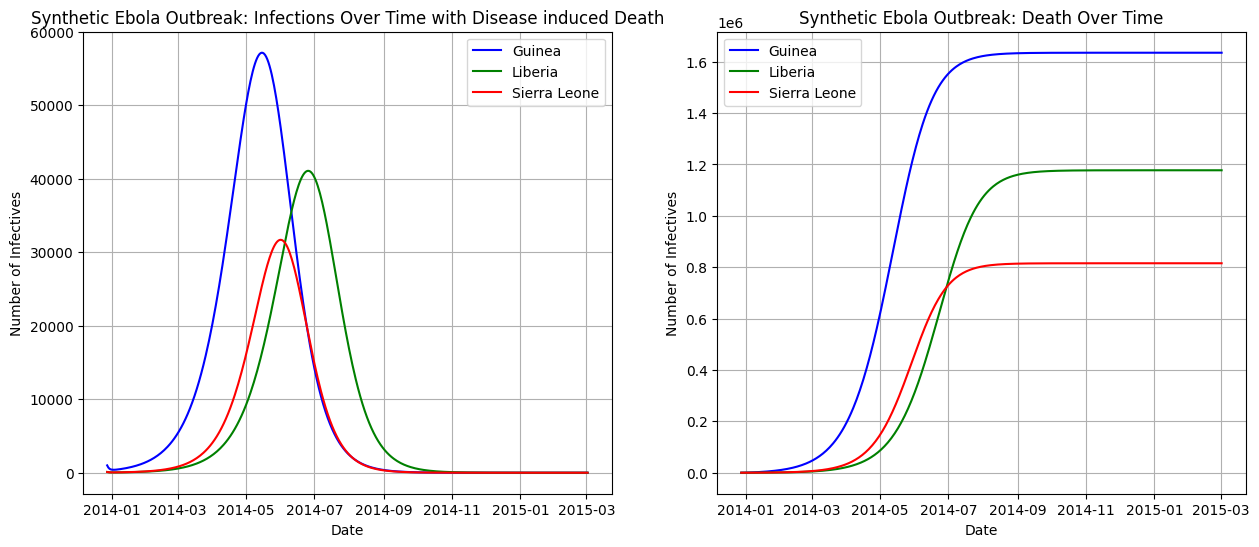

In [16]:
# Extract data for plotting
days = df['Date']
I_guinea = df['I_Guinea']
I_liberia = df['I_Liberia']
I_sierra_leone = df['I_SierraLeone']

# Create the plot
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
ax[0].plot(days, I_guinea, label='Guinea', color='blue')
ax[0].plot(days, I_liberia, label='Liberia', color='green')
ax[0].plot(days, I_sierra_leone, label='Sierra Leone', color='red')
ax[0].set_xlabel('Date')
ax[0].set_ylabel('Number of Infectives')
ax[0].set_title('Synthetic Ebola Outbreak: Infections Over Time with Disease induced Death')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(days, df['D_Guinea'], label='Guinea', color='blue')
ax[1].plot(days, df['D_Liberia'], label='Liberia', color='green')
ax[1].plot(days, df['D_SierraLeone'], label='Sierra Leone', color='red')
ax[1].set_xlabel('Date')
ax[1].set_ylabel('Number of Infectives')
ax[1].set_title('Synthetic Ebola Outbreak: Death Over Time')
ax[1].legend()
ax[1].grid(True)

# Save and show the plot
# plt.savefig('ebola_infections_disease_death_plot.png')
plt.show()

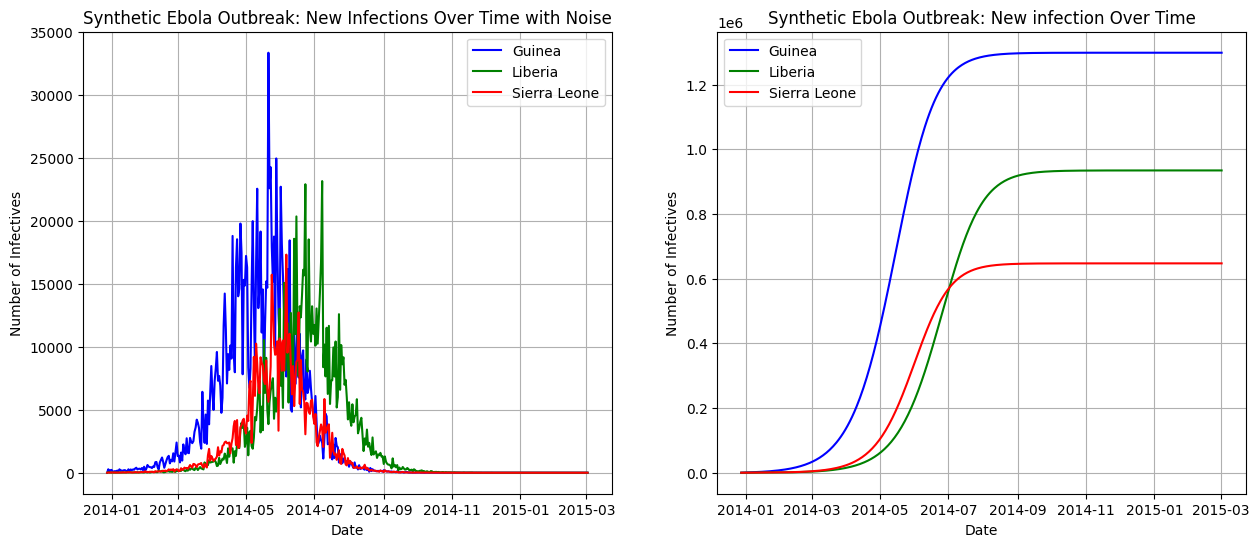

In [17]:
# Extract data for plotting
days = df['Date']
I_guinea = df['Noise_Guinea']
I_liberia = df['Noise_Liberia']
I_sierra_leone = df['Noise_SierraLeone']

# Create the plot
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
ax[0].plot(days, I_guinea, label='Guinea', color='blue')
ax[0].plot(days, I_liberia, label='Liberia', color='green')
ax[0].plot(days, I_sierra_leone, label='Sierra Leone', color='red')
ax[0].set_xlabel('Date')
ax[0].set_ylabel('Number of Infectives')
ax[0].set_title('Synthetic Ebola Outbreak: New Infections Over Time with Noise')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(days, df['C_Guinea'], label='Guinea', color='blue')
ax[1].plot(days, df['C_Liberia'], label='Liberia', color='green')
ax[1].plot(days, df['C_SierraLeone'], label='Sierra Leone', color='red')
ax[1].set_xlabel('Date')
ax[1].set_ylabel('Number of Infectives')
ax[1].set_title('Synthetic Ebola Outbreak: New infection Over Time')
ax[1].legend()
ax[1].grid(True)

# Save and show the plot
# plt.savefig('ebola_infections_disease_death_plot.png')
plt.show()

### 6 . Define a function to plot the SEIRD Compartments

In [18]:
# Plot for each country
countries = ['Guinea', 'Liberia', 'SierraLeone']
def plot_SEIR(df, country_name, Death = False, save=False, yscale = True):
    # Extract data for the current country
    S = df[f'S_{country_name}']
    E = df[f'E_{country_name}']
    I = df[f'I_{country_name}']
    R = df[f'R_{country_name}']

    # Create plot
    plt.figure(figsize=(13, 6))
    plt.plot(df['Date'], S, label='Susceptible', color='blue')
    plt.plot(df['Date'], E, label='Exposed', color='orange')
    plt.plot(df['Date'], I, label='Infective', color='red')
    plt.plot(df['Date'], R, label='Recovered', color='green')
    if Death:
        D = df[f'D_{country_name}']
        plt.plot(df['Date'], D, label='Death', color='black')

    # Customize the plot
    plt.xlabel('Date')
    plt.ylabel('Number of Individuals')
    plt.title(f'SEIRD Dynamics for {country_name}')
    plt.legend()
    plt.grid(True)
    if yscale:
        plt.yscale('symlog')  # Use symlog scale to handle large ranges
    if save:
        plt.savefig(f'seird_{country_name.lower()}.png')
    plt.show()

In [19]:
# plot_SEIR(df, 'Guinea', Death=True)

In [20]:
# plot_SEIR(df, 'Liberia', Death=True)

In [21]:
# plot_SEIR(df, 'SierraLeone', Death=True)

In [22]:
Noise

array([[  0,   0,   0],
       [275,  38,  12],
       [ 92,  14,  10],
       ...,
       [  0,   0,   0],
       [  0,   0,   0],
       [  0,   0,   0]], shape=(430, 3))

In [34]:
N_countries = 3
t = np.arange(1, T + 1)
t0 = 0
N = np.array([2e6, 1.5e6, 1e6]).astype(int)
I0 = np.array([1000.0, 100.0, 100.0])

cases = Noise.T

# Initial conditions: [S, E, I, R, D, CumInc]
y0 = np.zeros((N_countries, 6))
for c in range(N_countries):
    S0 = N[c] * 0.999 - I0[c]
    E0 = N[c] * 0.001
    y0[c, :] = [S0, E0, I0[c], 0.0, 0.0, 0.0]

# Initial conditions for coupling terms: [S_ij, E_ij, I_ij, R_ij, D_ij]
y0_ij = np.zeros((N_countries, N_countries, 5))  # Assume no initial movement

# 2. Prepare data dictionary
stan_data = {
    'N_countries': N_countries,
    'n_days': T,
    'y0': y0,
    'y0_ij': y0_ij,
    't0': t0,
    't': t,
    'N': N,
    'cases': cases
}

stan_model = CmdStanModel(stan_file='stan files/patch_with_coupling.stan')

In [35]:
stan_data['cases']

array([[  0, 275,  92, ...,   0,   0,   0],
       [  0,  38,  14, ...,   0,   0,   0],
       [  0,  12,  10, ...,   0,   0,   0]], shape=(3, 430))

In [36]:
# Compile and run the Stan model
# model = CmdStanModel(stan_file='multi_patch.stan')
fit = stan_model.sample(data=stan_data,
                   chains=4,
                   iter_warmup=100,
                   iter_sampling=100)

chain 1 |          | 00:00 Status


chain 1 |██████████| 00:00 Sampling completed
chain 2 |██████████| 00:00 Sampling completed
chain 3 |██████████| 00:00 Sampling completed
chain 4 |██████████| 00:00 Sampling completed

RuntimeError: Error during sampling:
Exception: Exception: array[uni, ...] index: accessing element out of range. index 10 out of range; expecting index to be between 1 and 9 (in 'patch_with_coupling.stan', line 63, column 8 to column 45) (in 'patch_with_coupling.stan', line 170, column 4 to column 121)
Exception: Exception: array[uni, ...] index: accessing element out of range. index 10 out of range; expecting index to be between 1 and 9 (in 'patch_with_coupling.stan', line 63, column 8 to column 45) (in 'patch_with_coupling.stan', line 170, column 4 to column 121)
Exception: Exception: array[uni, ...] index: accessing element out of range. index 10 out of range; expecting index to be between 1 and 9 (in 'patch_with_coupling.stan', line 63, column 8 to column 45) (in 'patch_with_coupling.stan', line 170, column 4 to column 121)
Exception: Exception: array[uni, ...] index: accessing element out of range. index 10 out of range; expecting index to be between 1 and 9 (in 'patch_with_coupl

$$incidence_i = \sigma × (E_{ii} + \sum_{j\neq i} E_{ji})$$

In [ ]:
print(fit.diagnose())

Checking sampler transitions treedepth.
400 of 100 (400.00%) transitions hit the maximum treedepth limit of 10, or 2^10 leapfrog steps.
Trajectories that are prematurely terminated due to this limit will result in slow exploration.
For optimal performance, increase this limit.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
The E-BFMI, 0.02, is below the nominal threshold of 0.30 which suggests that HMC may have trouble exploring the target distribution.
If possible, try to reparameterize the model.

Rank-normalized split effective sample size satisfactory for all parameters.

The following parameters had rank-normalized split R-hat greater than 1.01:
  predicted_cases[2,1], predicted_cases[3,1], predicted_cases[4,1], predicted_cases[5,1], predicted_cases[6,1], predicted_cases[7,1], predicted_cases[8,1], predicted_cases[9,1], predicted_cases[10,1], predicted_cases[11,1], predicted_cases[12,1], p

In [ ]:
fit.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
lp__,-3.777510e+10,NaN,4.151230e+10,3.681930e+10,-1.004140e+11,-2.517510e+10,-3.362960e+08,NaN,NaN,NaN
beta[1],1.836890e+00,NaN,1.184340e+00,1.408140e+00,4.541670e-01,1.695070e+00,3.503270e+00,NaN,NaN,NaN
beta[2],6.275700e-01,NaN,3.199810e-01,3.506340e-01,1.772810e-01,6.925300e-01,9.479380e-01,NaN,NaN,NaN
beta[3],1.345950e+00,NaN,1.446600e+00,5.784830e-01,1.507670e-01,7.154360e-01,3.802170e+00,NaN,NaN,NaN
phi_inv,3.854550e+00,NaN,2.096970e+00,7.952150e-01,2.931060e-01,4.822640e+00,5.479840e+00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
"predicted_cases[999,2]",2.000000e-02,NaN,1.862440e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN,NaN
"predicted_cases[999,3]",2.500000e-03,NaN,5.000000e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN,NaN
"predicted_cases[1000,1]",6.182500e+00,NaN,2.842250e+01,0.000000e+00,0.000000e+00,0.000000e+00,2.805000e+01,NaN,NaN,NaN
"predicted_cases[1000,2]",1.150000e-01,NaN,6.463900e-01,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e-02,NaN,NaN,NaN


# 2 . Without Disease induced Deaths

### simple model without Death compartment

---
### Residents of patch i currently in patch i

---

$$
\begin{aligned}
{S'}_{ii} &= -\sum_{k=1}^n \beta_{ik} \frac{S_{ii} I_{kj}}{N_j} + \sum_{k=1}^n r_{ij} S_{ii} - g_i S_{ii} \\
{E'}_{ii} &= \sum_{k=1}^n \beta_{ik} \frac{S_{ii} I_{kj}}{N_j} - \sigma E_{ii} + \sum_{k=1}^n r_{ij} E_{ii} - g_i E_{ii} \\
{I'}_{ii} &= \sigma E_{ii} - \gamma I_{ii} + \sum_{k=1}^n r_{ij} I_{ii} - g_i I_{ii} \\
{R'}_{ii} &= \gamma I_{ii} + \sum_{k=1}^n r_{ij} R_{ii} - g_i R_{ii}
\end{aligned}
$$

---
### Residents of patch i currently in patch j

---
$$
\begin{aligned}
S'_{ij} &= -\sum_{k=1}^n k_j \beta_{ikj}\frac{S_{ij}I_{kj}}{N_j} + g_i m_{ji}S_{ii} - r_{ij}S_{ij}\\
E'_{ij} &= \sum_{k=1}^n k_j \beta_{ikj}\frac{S_{ij}I_{kj}}{N_j} - \sigma E_{ij} + g_i m_{ji}E_{ii} - r_{ij}E_{ij}\\
I'_{ij} &= \sigma E_{ij} - \gamma I_{ij} + g_im_{ji}I_{ii} - r_{ij}I_{ij}\\
R'_{ij} &= \gamma I_{ij} + g_im_{ji}R_{ii} - r_{ij}R_{ij}
\end{aligned}
$$


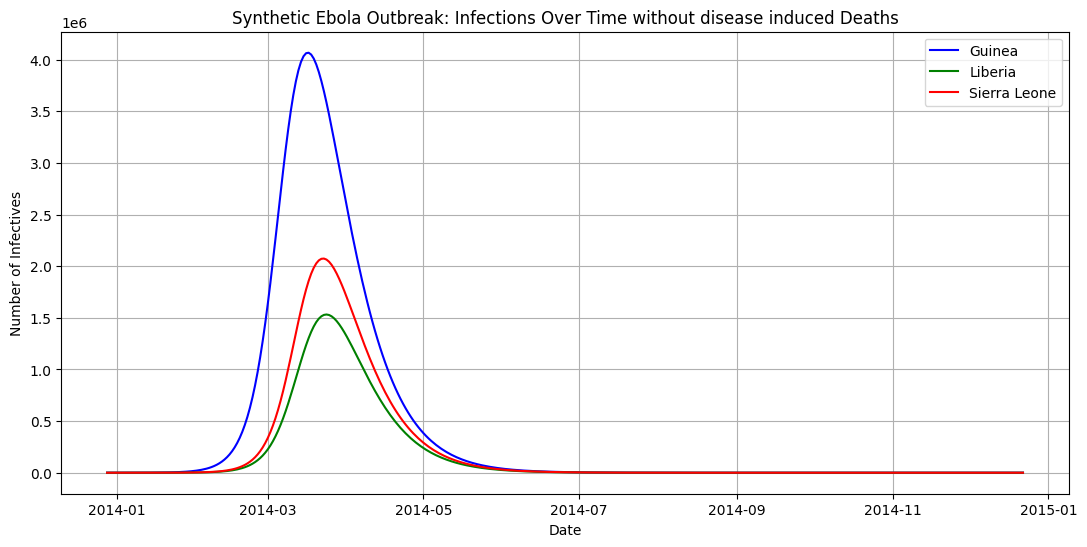

In [ ]:
n = 3
 ## Population per patch (Guinea, Liberia, Sierra Leone)
N = np.array([12e6, 4.5e6, 6e6])

### 8·5 days (7·7–9·2) for the incubation period, 
### 9·3 days (8·5–10·1) for the symptom-onset-to-death delay,
### 13·0 days (10·4–15·7) for symptom-onset-to-recovery

sigma = 1/8.5  # Latent period (~7 days)
gamma = 1/13  # Recovery rate (~10 days)
kappa = np.array([2.0, 1.5, 1.8])  # Contact rates
beta = np.array([0.3, 0.4, 0.35]) #[0.06, 0.07, 0.08])  # Transmission probabilities

## Travel and return rate
g = np.array([0.001, 0.001, 0.001])  # Travel rates
m = np.array([[0, 0.5, 0.5], [0.5, 0, 0.5], [0.5, 0.5, 0]])  # Travel fractions
r = np.array([[0, 0.5, 0.5], [0.5, 0, 0.5], [0.5, 0.5, 0]])  # Return rates

# Initial conditions: Small outbreak in Guinea
S01 = np.zeros((n, n))
E01 = np.zeros((n, n))
I01 = np.zeros((n, n))
R01 = np.zeros((n, n))

## get the number of individuals currently in the patches and those traveled
for i in range(n):
    S01[i, i] = N[i] * 0.99
    S01[i, (i+1)%n] = N[i] * 0.005
    S01[i, (i+2)%n] = N[i] * 0.005

# Initial infectives in Guinea
I01[0, 0] = 100
S01[0, 0] -= 100

# Initial infectives in Liberia
I01[1,1] = 10
S01[1,1] -= 10

# Initial infectives in Sierra Leone
I01[2,2] = 10
S01[2,2] -= 10

y01 = np.concatenate([S01.flatten(), E01.flatten(), I01.flatten(), R01.flatten()])

# Model equations
def model1(y, t, n, N, sigma, gamma, kappa, beta, g, m, r):
    S = y[:n*n].reshape(n, n)
    E = y[n*n:2*n*n].reshape(n, n)
    I = y[2*n*n:3*n*n].reshape(n, n)
    R = y[3*n*n:].reshape(n, n)

    Np = np.sum(S + E + I + R, axis=0)  # Population in each patch
    dSdt = np.zeros((n, n))
    dEdt = np.zeros((n, n))
    dIdt = np.zeros((n, n))
    dRdt = np.zeros((n, n))

    for i in range(n):
        ## Calculate ds_dt for the Residents of Patch i currently in Patch i
        j = i

        ## create the force infection
        foi = sum(kappa[j] * beta[j] * S[i, j] * I[k, j] / Np[j] for k in range(n))

        ## calculate the change in the compartments
        dSdt[i, i] = - foi + sum(r[i, k] * S[i, k] for k in range(n)) - g[i] * S[i, i]
        dEdt[i, i] = foi - sigma * E[i, i] + sum(r[i, k] * E[i, k] for k in range(n)) - g[i] * E[i, i]
        dIdt[i, i] = sigma * E[i, i] - gamma * I[i, i] + sum(r[i, k] * I[i, k] for k in range(n)) - g[i] * I[i, i]
        dRdt[i, i] = gamma * I[i, i] + sum(r[i, k] * R[i, k] for k in range(n)) - g[i] * R[i, i]

        ## Calculate ds_dt for the Residents of Patch i currently in Patch j
        # for j in range(n):
        #     if j != i:
        #         ## create force of infection
        #         foi = sum(kappa[j] * beta[j] * S[i, j] * I[k, j] / Np[j] for k in range(n))

        #         ## calculate the change in the compartments
        #         dSdt[i, j] =  - foi + g[i] * m[j, i] * S[i, i] - r[i, j] * S[i, j]
        #         dEdt[i, j] = foi - sigma * E[i, j] + g[i] * m[j, i] * E[i, i] - r[i, j] * E[i, j]
        #         dIdt[i, j] = sigma * E[i, j] - gamma * I[i, j] + g[i] * m[j, i] * I[i, i] - r[i, j] * I[i, j]
        #         dRdt[i, j] = gamma * I[i, j] + g[i] * m[j, i] * R[i, i] - r[i, j] * R[i, j]

    return np.concatenate([dSdt.flatten(), dEdt.flatten(), dIdt.flatten(), dRdt.flatten()])


T=360
## Solve ODE
t = np.linspace(0, T, T)
sol1 = odeint(model1, y01, t, args=(n, N, sigma, gamma, kappa, beta, g, m, r))

## Extract and aggregate results
S1 = sol1[:, :n*n].reshape(-1, n, n)
E1 = sol1[:, n*n:2*n*n].reshape(-1, n, n)
I1 = sol1[:, 2*n*n:3*n*n].reshape(-1, n, n)
R1 = sol1[:, 3*n*n:].reshape(-1, n, n)

## Total per patch (sum over resident patches i)
S_total1 = np.sum(S1, axis=1)
E_total1 = np.sum(E1, axis=1)
I_total1 = np.sum(I1, axis=1)
R_total1 = np.sum(R1, axis=1)

## Create dataset with time, totals per patch, and parameters
data1= {
    'Date': pd.date_range(start='2013-12-28', periods=T, freq='D'),
    'Day': t.astype(int),
    'S_Guinea': S_total1[:, 0],
    'E_Guinea': E_total1[:, 0],
    'I_Guinea': I_total1[:, 0],
    'R_Guinea': R_total1[:, 0],

    'S_Liberia': S_total1[:, 1],
    'E_Liberia': E_total1[:, 1],
    'I_Liberia': I_total1[:, 1],
    'R_Liberia': R_total1[:, 1],

    'S_SierraLeone': S_total1[:, 2],
    'E_SierraLeone': E_total1[:, 2],
    'I_SierraLeone': I_total1[:, 2],
    'R_SierraLeone': R_total1[:, 2],
    
    'Travel_Rate_Guinea': np.full(T, g[0]),
    'Travel_Rate_Liberia': np.full(T, g[1]),
    'Travel_Rate_SierraLeone': np.full(T, g[2]),
    'Contact_Rate_Guinea': np.full(T, kappa[0]),
    'Contact_Rate_Liberia': np.full(T, kappa[1]),
    'Contact_Rate_SierraLeone': np.full(T, kappa[2])
}

## Convert to a dataframe
df1 = pd.DataFrame(data1)
df.to_csv('synthetic_nodeath.csv', index=False)
# print("Synthetic dataset saved as 'synthetic_ebola_dataset.csv'")

## Extract data for plotting
days = df1['Date']
I_guinea1 = df1['I_Guinea']
I_liberia1 = df1['I_Liberia']
I_sierra_leone1 = df1['I_SierraLeone']

## Create the plot
plt.figure(figsize=(13, 6))
plt.plot(days, I_guinea1, label='Guinea', color='blue')
plt.plot(days, I_liberia1, label='Liberia', color='green')
plt.plot(days, I_sierra_leone1, label='Sierra Leone', color='red')

## Customize the plot
plt.xlabel('Date')
plt.ylabel('Number of Infectives')
plt.title('Synthetic Ebola Outbreak: Infections Over Time without disease induced Deaths')
plt.legend()
plt.grid(True)

## Save and show the plot
# plt.savefig('ebola_infections_plot.png')
plt.show()

In [128]:
df1

,Date,Day,S_Guinea,E_Guinea,I_Guinea,R_Guinea,S_Liberia,E_Liberia,I_Liberia,R_Liberia,S_SierraLeone,E_SierraLeone,I_SierraLeone,R_SierraLeone,Travel_Rate_Guinea,Travel_Rate_Liberia,Travel_Rate_SierraLeone,Contact_Rate_Guinea,Contact_Rate_Liberia,Contact_Rate_SierraLeone
0,2013-12-28,0,1.193240e+07,0.000000,100.000000,0.000000e+00,4.544990e+06,0.000000,10.000000,0.000000e+00,6.022490e+06,0.000000,10.000000,0.000000e+00,0.001,0.001,0.001,2.0,1.5,1.8
1,2013-12-29,1,1.195368e+07,55.162572,95.766913,7.503916e+00,4.530760e+06,5.546914,9.618014,7.536030e-01,6.015372e+06,5.841703,9.635611,7.540678e-01,0.001,0.001,0.001,2.0,1.5,1.8
2,2013-12-30,2,1.196653e+07,103.584756,97.703869,1.492517e+01,4.522147e+06,10.456218,9.840961,1.502936e+00,6.011062e+06,11.044984,9.909940,1.506631e+00,0.001,0.001,0.001,2.0,1.5,1.8
3,2013-12-31,3,1.197428e+07,149.231014,104.813063,2.269957e+01,4.516933e+06,15.106334,10.580667,2.289965e+00,6.008452e+06,16.012353,10.733253,2.302270e+00,0.001,0.001,0.001,2.0,1.5,1.8
4,2014-01-01,4,1.197894e+07,195.184639,116.573478,3.120400e+01,4.513775e+06,19.801370,11.790602,3.152203e+00,6.006869e+06,21.075088,12.060065,3.181008e+00,0.001,0.001,0.001,2.0,1.5,1.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,2014-12-18,355,4.925087e+03,0.000056,0.009353,1.198160e+07,1.853212e+03,0.000036,0.006113,4.507129e+06,1.673820e+03,0.000030,0.007007,6.002817e+06,0.001,0.001,0.001,2.0,1.5,1.8
356,2014-12-19,356,4.925087e+03,0.000052,0.008664,1.198160e+07,1.853212e+03,0.000034,0.005663,4.507129e+06,1.673820e+03,0.000028,0.006490,6.002817e+06,0.001,0.001,0.001,2.0,1.5,1.8
357,2014-12-20,357,4.925087e+03,0.000048,0.008027,1.198160e+07,1.853212e+03,0.000031,0.005246,4.507129e+06,1.673820e+03,0.000026,0.006011,6.002817e+06,0.001,0.001,0.001,2.0,1.5,1.8
358,2014-12-21,358,4.925087e+03,0.000044,0.007436,1.198160e+07,1.853212e+03,0.000029,0.004860,4.507129e+06,1.673820e+03,0.000024,0.005568,6.002817e+06,0.001,0.001,0.001,2.0,1.5,1.8


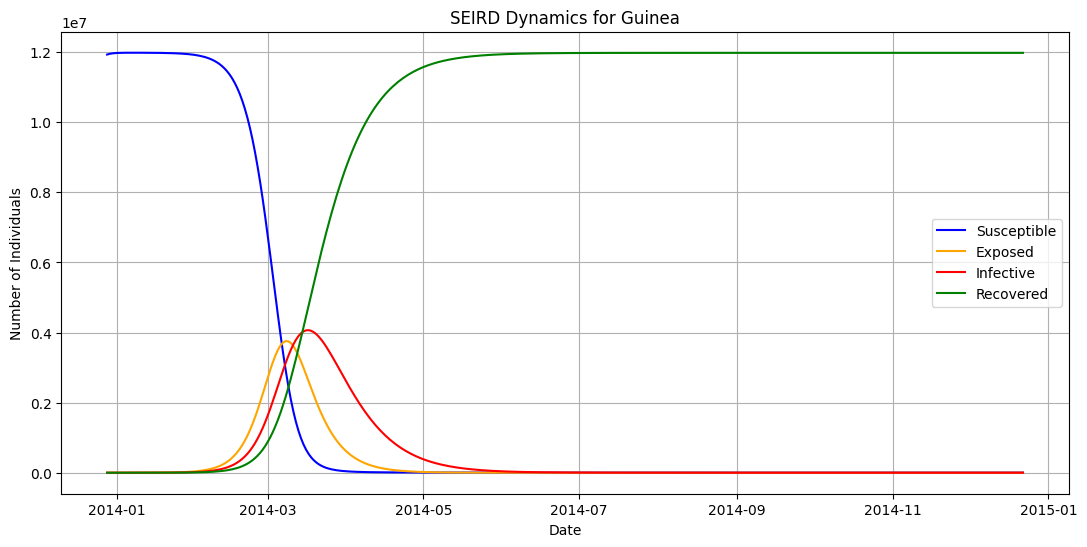

In [129]:
plot_SEIR(df1, 'Guinea', yscale=False)

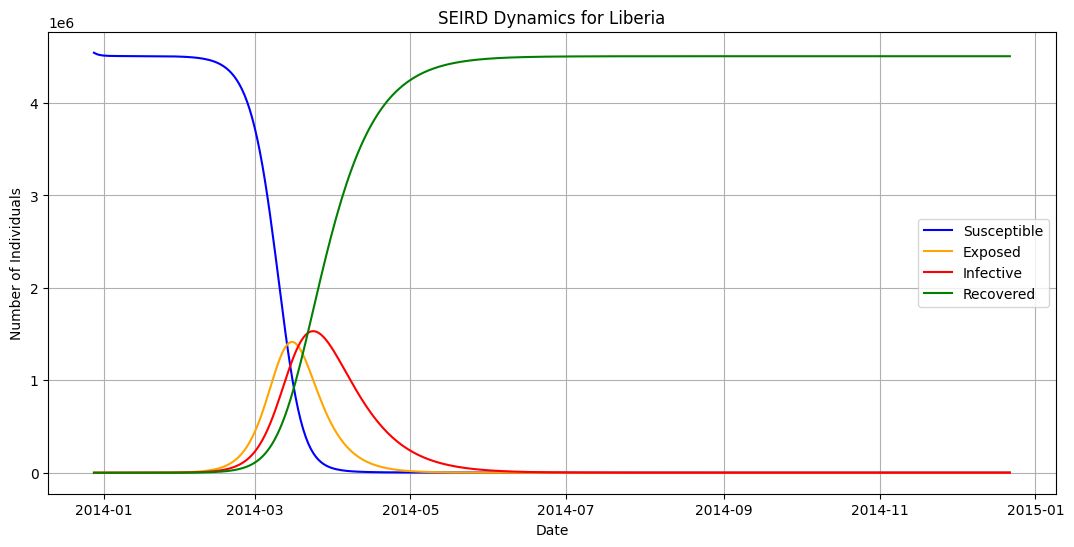

In [130]:
plot_SEIR(df1, 'Liberia', yscale=False)

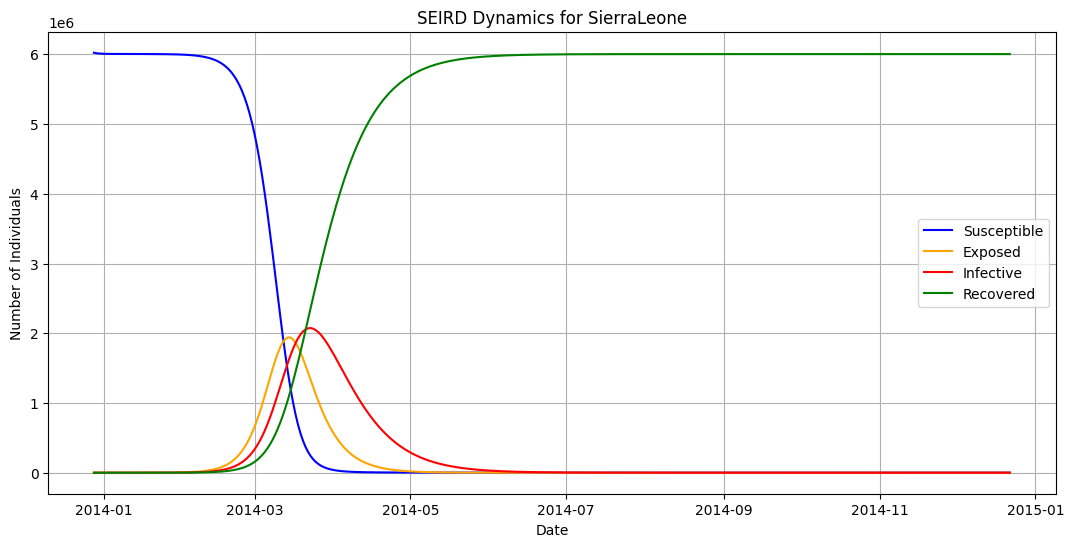

In [131]:
plot_SEIR(df1, 'SierraLeone', yscale=False)

In [122]:
# Load the synthetic dataset
df = pd.read_csv('synthetic_ebola_dataset_with_death.csv')

# Prepare data for Stan
P = 3
T = len(df)
t0 = -1
ts = df['Day'].values
I_obs = df[['I_Guinea', 'I_Liberia', 'I_SierraLeone']].values.astype(int)
D_obs = df[['D_Guinea', 'D_Liberia', 'D_SierraLeone']].values.astype(int)
N = np.array([12e6, 4.5e6, 6e6])
E0 = np.array([0, 0, 0])
I0 = np.array([100, 0, 0])

stan_data = {
    'P': P,
    'T': T,
    't0': t0,
    'ts': ts,
    'I_obs': I_obs,
    'D_obs': D_obs,
    'N': N,
    'E0': E0,
    'I0': I0
}

In [ ]:
# Compile and run the Stan model
model = CmdStanModel(stan_file='coupling.stan')
fit = model.sample(data=stan_data,
                   chains=4,
                   parallel_chains=4,
                   iter_warmup=10,
                   iter_sampling=10)

ValueError: no such file /var/autofs/misc/home/samuela/Documents/thesis/myvenv/thesis/coupling.stan

In [ ]:
# Summarize results
print(fit.summary())
fit.save_csvfiles('stan_output_seird')
print("Stan output saved in 'stan_output_seird' directory")